# 18 — Model v4.1 Improvements
## RentSignal — R² Improvement Pipeline

**Goal:** Push R² from 0.708 → 0.75+ through better data handling, feature engineering, NLP features, and hyperparameter tuning.

**Steps:**
1. Better missing data imputation (yearConstructed, thermalChar, floor)
2. Feature engineering (heatingType grouping, interactions, log target, size categories)
3. NLP title features (Altbau, Neubau, möbliert, Tauschwohnung, Erstbezug)
4. Quick features (picturecount, Nebenkosten/m²)
5. Hyperparameter tuning (RandomizedSearchCV, laptop-friendly)
6. Retrain & evaluate v4.1

In [2]:
import sys, json, hashlib, re, warnings
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
import shap
import joblib
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('..').resolve()
PROC_DIR = PROJECT_ROOT / 'data' / 'processed'
RAW_DIR  = PROJECT_ROOT / 'data' / 'raw'
MODEL_DIR = PROJECT_ROOT / 'models'

# Load base tables
units = pd.read_parquet(PROC_DIR / 'units.parquet')
listings = pd.read_parquet(PROC_DIR / 'listings.parquet')
spatial = pd.read_parquet(PROC_DIR / 'spatial_unit.parquet')

# Load raw JSON for title mining + extra fields
RAW_FILE = RAW_DIR / 'scraping' / 'dataset_immobilienscout24-scraper_2026-03-18_23-03-51-178.json'
with open(RAW_FILE, encoding='utf-8') as f:
    raw = json.load(f)

# Build scout_id → raw record lookup
raw_lookup = {}
for r in raw:
    sid = str(r.get('adTargetingParameters', {}).get('obj_scoutId', ''))
    raw_lookup[sid] = r

print(f'Units: {len(units):,}, Listings: {len(listings):,}, Spatial: {len(spatial):,}')
print(f'Raw records indexed: {len(raw_lookup):,}')

Units: 8,256, Listings: 8,256, Spatial: 8,250
Raw records indexed: 8,333


## Step 1: Better Missing Data Imputation

In [4]:
# Merge into single training DataFrame
df = units.merge(listings[['unit_id', 'rent_sqm', 'baseRent', 'totalRent', 'serviceCharge']], on='unit_id')
df = df.merge(spatial.drop(columns=['coord_source']), on='unit_id', how='left')

print(f'Before imputation:')
print(f'  yearConstructed missing: {df["yearConstructed"].isna().sum()} ({100*df["yearConstructed"].isna().mean():.1f}%)')
print(f'  thermalChar missing:     {df["thermalChar"].isna().sum()} ({100*df["thermalChar"].isna().mean():.1f}%)')
print(f'  floor missing:           {df["floor"].isna().sum()} ({100*df["floor"].isna().mean():.1f}%)')

# --- 1a. yearConstructed from title keywords ---
def infer_year_from_title(scout_id):
    """Infer approximate yearConstructed from listing title keywords."""
    rec = raw_lookup.get(scout_id)
    if not rec:
        return None
    title = rec.get('basicInfo', {}).get('title', '').lower()
    
    if 'erstbezug' in title or 'neubau' in title:
        return 2024  # Recently built
    if 'altbau' in title:
        return 1905  # Typical Wilhelminian era
    # Check for explicit year mentions
    m = re.search(r'(19|20)\d{2}', title)
    if m:
        year = int(m.group())
        if 1850 <= year <= 2027:
            return year
    return None

year_before = df['yearConstructed'].isna().sum()
mask = df['yearConstructed'].isna()
df.loc[mask, 'yearConstructed'] = df.loc[mask, 'scout_id'].apply(infer_year_from_title)
year_after = df['yearConstructed'].isna().sum()
print(f'\n  yearConstructed: recovered {year_before - year_after} from title keywords')

# --- 1b. floor from typeOfFlat ---
floor_before = df['floor'].isna().sum()
type_floor_map = {
    'ground_floor': 0, 'raised_ground_floor': 0,
    'half_basement': -1, 'souterrain': -1,
    'penthouse': 8,  # approximate
    'roof_storey': 6,
}
for flat_type, floor_val in type_floor_map.items():
    mask = (df['floor'].isna()) & (df['typeOfFlat'] == flat_type)
    df.loc[mask, 'floor'] = floor_val
floor_after = df['floor'].isna().sum()
print(f'  floor: recovered {floor_before - floor_after} from typeOfFlat')

# --- 1c. thermalChar conditional medians by heatingType ---
thermal_before = df['thermalChar'].isna().sum()
thermal_by_heat = df.groupby('heatingType')['thermalChar'].median()
for ht, median_val in thermal_by_heat.items():
    if pd.notna(median_val):
        mask = (df['thermalChar'].isna()) & (df['heatingType'] == ht)
        df.loc[mask, 'thermalChar'] = median_val
thermal_after = df['thermalChar'].isna().sum()
print(f'  thermalChar: recovered {thermal_before - thermal_after} using heatingType-conditional medians')

# Recalculate building_era for newly recovered years
sys.path.insert(0, str(PROJECT_ROOT))
from data.pipelines.ingestion import year_to_building_era
era_before_unknown = (df['building_era'] == 'unknown').sum()
df['building_era'] = df['yearConstructed'].apply(year_to_building_era)
era_after_unknown = (df['building_era'] == 'unknown').sum()
print(f'  building_era: {era_before_unknown - era_after_unknown} units upgraded from unknown')

print(f'\nAfter imputation:')
print(f'  yearConstructed missing: {df["yearConstructed"].isna().sum()} ({100*df["yearConstructed"].isna().mean():.1f}%)')
print(f'  thermalChar missing:     {df["thermalChar"].isna().sum()} ({100*df["thermalChar"].isna().mean():.1f}%)')
print(f'  floor missing:           {df["floor"].isna().sum()} ({100*df["floor"].isna().mean():.1f}%)')

Before imputation:
  yearConstructed missing: 5652 (68.5%)
  thermalChar missing:     6540 (79.2%)
  floor missing:           3818 (46.2%)

  yearConstructed: recovered 574 from title keywords
  floor: recovered 190 from typeOfFlat
  thermalChar: recovered 6524 using heatingType-conditional medians
  building_era: 574 units upgraded from unknown

After imputation:
  yearConstructed missing: 5078 (61.5%)
  thermalChar missing:     16 (0.2%)
  floor missing:           3628 (43.9%)


## Step 2 & 3: Feature Engineering + NLP Title Features

In [5]:
# --- 2a. Collapse heatingType into ~8 groups ---
HEATING_GROUPS = {
    'gas': ['gas', 'natural_gas', 'liquid_gas'],
    'district': ['district_heating'],
    'oil': ['oil'],
    'electric': ['electric', 'electricity', 'night_storage_heater'],
    'heat_pump': ['heat_pump', 'geothermal', 'environmental_thermal_energy',
                  'solar_heating', 'air_water_heat_pump'],
    'central': ['central_heating', 'self_contained_central_heating'],
    'floor': ['floor_heating', 'underfloor_heating'],
    'combined': ['combined_heat_and_power_fossil_fuels', 'combined_heat_and_power_plant',
                 'combined_heat_and_power_regenerative_energy', 'combined_heat_and_power_renewable_energy'],
}

def group_heating(ht):
    ht_lower = str(ht).lower().strip()
    for group, keywords in HEATING_GROUPS.items():
        for kw in keywords:
            if kw in ht_lower:
                return group
    return 'unknown'

df['heatingGroup'] = df['heatingType'].apply(group_heating)
print('heatingGroup distribution:')
print(df['heatingGroup'].value_counts().to_string())

# --- 2b. Size category ---
def size_category(sqm):
    if sqm < 30: return 'micro'
    if sqm < 50: return 'small'
    if sqm < 70: return 'medium'
    if sqm < 100: return 'large'
    return 'xlarge'

df['sizeCategory'] = df['livingSpace'].apply(size_category)
print(f'\nsizeCategory distribution:')
print(df['sizeCategory'].value_counts().to_string())

# --- 3. NLP title features ---
def extract_title_features(scout_id):
    """Extract binary features from listing title."""
    rec = raw_lookup.get(scout_id)
    if not rec:
        return {}
    title = rec.get('basicInfo', {}).get('title', '').lower()
    atp = rec.get('adTargetingParameters', {})
    
    return {
        'is_altbau': int('altbau' in title),
        'is_neubau': int('neubau' in title or 'erstbezug' in title),
        'is_furnished': int('möbliert' in title or 'furnished' in title or 'möbel' in title),
        'is_tauschwohnung': int('tausch' in title),
        'is_renovated': int('saniert' in title or 'renoviert' in title or 'modernisiert' in title),
        'is_wg': int('wg' in title or 'wohngemeinschaft' in title),
        'is_befristet': int('befristet' in title or 'zwischenmiete' in title),
        'has_terrasse': int('terrasse' in title or 'dachterrasse' in title),
        'is_dachgeschoss': int('dachgeschoss' in title or 'dg' in title),
        'picturecount': int(atp.get('obj_picturecount', 0) or 0),
    }

title_features = pd.DataFrame([extract_title_features(sid) for sid in df['scout_id']])
title_features.index = df.index

for col in title_features.columns:
    df[col] = title_features[col]

print(f'\nTitle feature extraction:')
for col in title_features.columns:
    if col == 'picturecount':
        print(f'  {col}: mean={df[col].mean():.1f}, median={df[col].median():.0f}')
    else:
        print(f'  {col}: {df[col].sum()} ({100*df[col].mean():.1f}%)')

# --- 2c. Nebenkosten per m² ---
df['nebenkosten_sqm'] = df['serviceCharge'] / df['livingSpace'].replace(0, np.nan)
valid_nk = df['nebenkosten_sqm'].notna().sum()
print(f'\n  nebenkosten_sqm: {valid_nk} valid ({100*valid_nk/len(df):.1f}%), median={df["nebenkosten_sqm"].median():.2f}')

heatingGroup distribution:
heatingGroup
unknown      5874
district     1109
gas           750
combined      150
oil           104
central        97
electric       79
heat_pump      63
floor          30

sizeCategory distribution:
sizeCategory
medium    2902
large     2237
small     1564
xlarge    1078
micro      475

Title feature extraction:
  is_altbau: 573 (6.9%)
  is_neubau: 512 (6.2%)
  is_furnished: 657 (8.0%)
  is_tauschwohnung: 3428 (41.5%)
  is_renovated: 264 (3.2%)
  is_wg: 110 (1.3%)
  is_befristet: 65 (0.8%)
  has_terrasse: 345 (4.2%)
  is_dachgeschoss: 261 (3.2%)
  picturecount: mean=8.9, median=8

  nebenkosten_sqm: 4516 valid (54.7%), median=3.27


## Step 4: Prepare Feature Matrix (v4.1)

In [6]:
# --- Define v4.1 feature set ---

NUMERIC_FEATURES = [
    'livingSpace', 'noRooms', 'yearConstructed', 'floor', 'numberOfFloors',
    'thermalChar', 'sqm_per_room', 'nebenkosten_sqm', 'picturecount',
]

BINARY_FEATURES = [
    'balcony', 'hasKitchen', 'lift', 'cellar', 'garden', 'newlyConst',
    'is_altbau', 'is_neubau', 'is_furnished', 'is_tauschwohnung',
    'is_renovated', 'is_wg', 'is_befristet', 'has_terrasse', 'is_dachgeschoss',
]

CATEGORICAL_FEATURES = [
    'condition', 'interiorQual', 'typeOfFlat', 'heatingGroup',
    'building_era', 'bezirk', 'sizeCategory',
]

SPATIAL_FEATURES = [
    'dist_cbd_m', 'dist_transit_m', 'dist_ubahn_m',
    'dist_park_m', 'dist_water_m', 'dist_school_m',
    'count_food_500m', 'count_food_1000m',
    'count_restaurant_500m', 'count_restaurant_1000m',
    'count_cafe_500m',
    'count_shop_500m', 'count_shop_1000m',
    'count_transit_1000m',
    'count_building_200m',
    'ndvi_100m', 'ndvi_250m', 'ndvi_500m',
    'ndwi_100m', 'ndwi_250m', 'ndwi_500m',
    'ndbi_100m', 'ndbi_250m', 'ndbi_500m',
]

ALL_FEATURES = NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES + SPATIAL_FEATURES
TARGET = 'rent_sqm'

print(f'v4.1 feature set:')
print(f'  Numeric:     {len(NUMERIC_FEATURES)} (was 7, added nebenkosten_sqm, picturecount)')
print(f'  Binary:      {len(BINARY_FEATURES)} (was 6, added 9 NLP title features)')
print(f'  Categorical: {len(CATEGORICAL_FEATURES)} (was 6, replaced heatingType→heatingGroup, added sizeCategory)')
print(f'  Spatial:     {len(SPATIAL_FEATURES)} (same 24)')
print(f'  Total:       {len(ALL_FEATURES)} (was 43)')

# --- Prepare features ---

# Binary: ensure int
for col in BINARY_FEATURES:
    df[col] = df[col].astype(int)

# Numeric: fill remaining missing with median
for col in NUMERIC_FEATURES:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    n_miss = df[col].isna().sum()
    if n_miss > 0:
        df[col] = df[col].fillna(df[col].median())
        print(f'  {col}: filled {n_miss} remaining with median')

# Spatial: fill missing with 0
for col in SPATIAL_FEATURES:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Categorical: encode
for col in CATEGORICAL_FEATURES:
    df[col] = df[col].fillna('unknown').astype(str)

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df[CATEGORICAL_FEATURES] = encoder.fit_transform(df[CATEGORICAL_FEATURES])

X = df[ALL_FEATURES].copy()
y = df[TARGET].copy()

print(f'\nFeature matrix: {X.shape}')
print(f'Any NaN: {X.isna().any().any()}')

v4.1 feature set:
  Numeric:     9 (was 7, added nebenkosten_sqm, picturecount)
  Binary:      15 (was 6, added 9 NLP title features)
  Categorical: 7 (was 6, replaced heatingType→heatingGroup, added sizeCategory)
  Spatial:     24 (same 24)
  Total:       55 (was 43)
  yearConstructed: filled 5078 remaining with median
  floor: filled 3628 remaining with median
  numberOfFloors: filled 5534 remaining with median
  thermalChar: filled 16 remaining with median
  nebenkosten_sqm: filled 3740 remaining with median

Feature matrix: (8256, 55)
Any NaN: False


## Step 5: Hyperparameter Tuning (RandomizedSearchCV)

In [7]:
# Train/test split (same seed as v4.0 for fair comparison)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {len(X_train):,}, Test: {len(X_test):,}')

# --- RandomizedSearchCV (laptop-friendly: 30 iterations, 3-fold CV) ---
param_distributions = {
    'max_depth': [4, 5, 6, 7, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.08, 0.1],
    'min_child_weight': [3, 5, 7, 10],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'subsample': [0.7, 0.8, 0.9],
    'reg_alpha': [0, 0.01, 0.1, 0.5],
    'reg_lambda': [0.5, 1.0, 2.0, 5.0],
}

base_model = xgb.XGBRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    eval_metric='rmse',
)

print('Running RandomizedSearchCV (30 iterations, 3-fold CV)...')
print('This should take ~5-10 minutes on a laptop.\n')

search = RandomizedSearchCV(
    base_model,
    param_distributions,
    n_iter=30,
    cv=3,
    scoring='r2',
    random_state=42,
    verbose=1,
    n_jobs=1,  # Keep at 1 to avoid memory issues — XGBoost already uses all cores internally
)

search.fit(X_train, y_train)

print(f'\nBest R² (CV): {search.best_score_:.4f}')
print(f'Best params: {search.best_params_}')

Train: 6,604, Test: 1,652
Running RandomizedSearchCV (30 iterations, 3-fold CV)...
This should take ~5-10 minutes on a laptop.

Fitting 3 folds for each of 30 candidates, totalling 90 fits

Best R² (CV): 0.7157
Best params: {'subsample': 0.9, 'reg_lambda': 1.0, 'reg_alpha': 0, 'min_child_weight': 10, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 0.6}


## Step 6: Train Final v4.1 Model with Best Params + Early Stopping

In [8]:
# Train final model with best hyperparams + early stopping
best_params = search.best_params_

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42)

final_model = xgb.XGBRegressor(
    **best_params,
    n_estimators=2000,  # high cap, early stopping picks optimal
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
    eval_metric='rmse',
)

final_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=100)

print(f'\nBest iteration: {final_model.best_iteration}')
print(f'Best validation RMSE: {final_model.best_score:.4f}')

[0]	validation_0-rmse:7.95984
[100]	validation_0-rmse:4.42995
[200]	validation_0-rmse:4.29292
[300]	validation_0-rmse:4.27415
[343]	validation_0-rmse:4.27720

Best iteration: 293
Best validation RMSE: 4.2729


## Step 7: Evaluate v4.1 vs v4.0 vs v3

  MODEL COMPARISON
  Model                Data            Features       R²     RMSE      MAE
  --------------------------------------------------------------------
  v3.0 (Kaggle+PLZ)    2019 Kaggle           37   0.7491     2.59     1.70
  v4.0 (Apify+Unit)    2026 Apify            43   0.7083     4.21     3.07
  v4.1 (improved)      2026 Apify            55   0.7361     4.00     2.92
  --------------------------------------------------------------------
  v4.0 → v4.1:  ΔR² = +0.0278  ΔRMSE = -0.21

  Best hyperparams: {'subsample': 0.9, 'reg_lambda': 1.0, 'reg_alpha': 0, 'min_child_weight': 10, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 0.6}


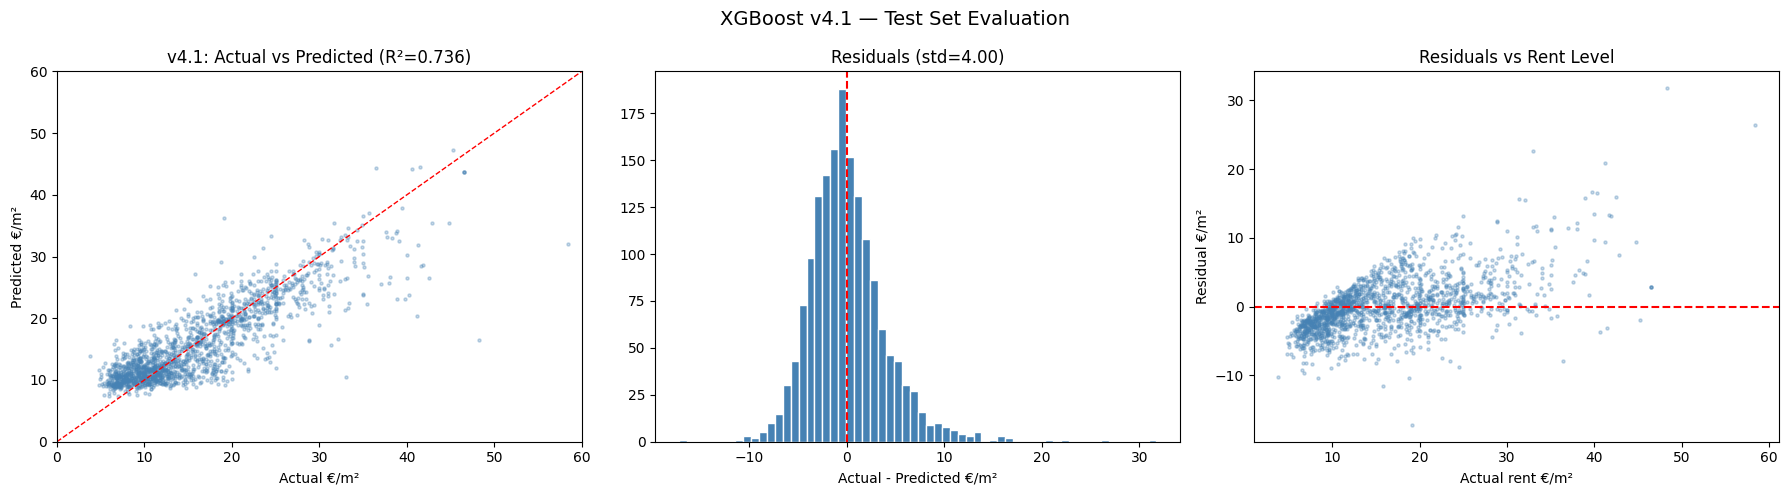

In [9]:
# Evaluate on held-out test set
y_pred = final_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print('=' * 60)
print('  MODEL COMPARISON')
print('=' * 60)
print(f'  {"Model":<20} {"Data":<15} {"Features":>8} {"R²":>8} {"RMSE":>8} {"MAE":>8}')
print(f'  {"-"*68}')
print(f'  {"v3.0 (Kaggle+PLZ)":<20} {"2019 Kaggle":<15} {"37":>8} {"0.7491":>8} {"2.59":>8} {"1.70":>8}')
print(f'  {"v4.0 (Apify+Unit)":<20} {"2026 Apify":<15} {"43":>8} {"0.7083":>8} {"4.21":>8} {"3.07":>8}')
print(f'  {"v4.1 (improved)":<20} {"2026 Apify":<15} {len(ALL_FEATURES):>8} {r2:>8.4f} {rmse:>8.2f} {mae:>8.2f}')
print(f'  {"-"*68}')
print(f'  v4.0 → v4.1:  ΔR² = {r2 - 0.7083:+.4f}  ΔRMSE = {rmse - 4.21:+.2f}')
print()
print(f'  Best hyperparams: {best_params}')

# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs Predicted
ax = axes[0]
ax.scatter(y_test, y_pred, s=5, alpha=0.3, c='steelblue')
ax.plot([0, 60], [0, 60], 'r--', linewidth=1)
ax.set_xlabel('Actual €/m²')
ax.set_ylabel('Predicted €/m²')
ax.set_title(f'v4.1: Actual vs Predicted (R²={r2:.3f})')
ax.set_xlim(0, 60)
ax.set_ylim(0, 60)

# Residuals
ax = axes[1]
residuals = y_test - y_pred
ax.hist(residuals, bins=60, color='steelblue', edgecolor='white')
ax.axvline(0, color='red', linestyle='--')
ax.set_title(f'Residuals (std={residuals.std():.2f})')
ax.set_xlabel('Actual - Predicted €/m²')

# Residuals by rent level
ax = axes[2]
ax.scatter(y_test, residuals, s=5, alpha=0.3, c='steelblue')
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('Actual rent €/m²')
ax.set_ylabel('Residual €/m²')
ax.set_title('Residuals vs Rent Level')

plt.suptitle('XGBoost v4.1 — Test Set Evaluation', fontsize=14)
plt.tight_layout()
plt.show()

## Step 8: SHAP Analysis (v4.1)

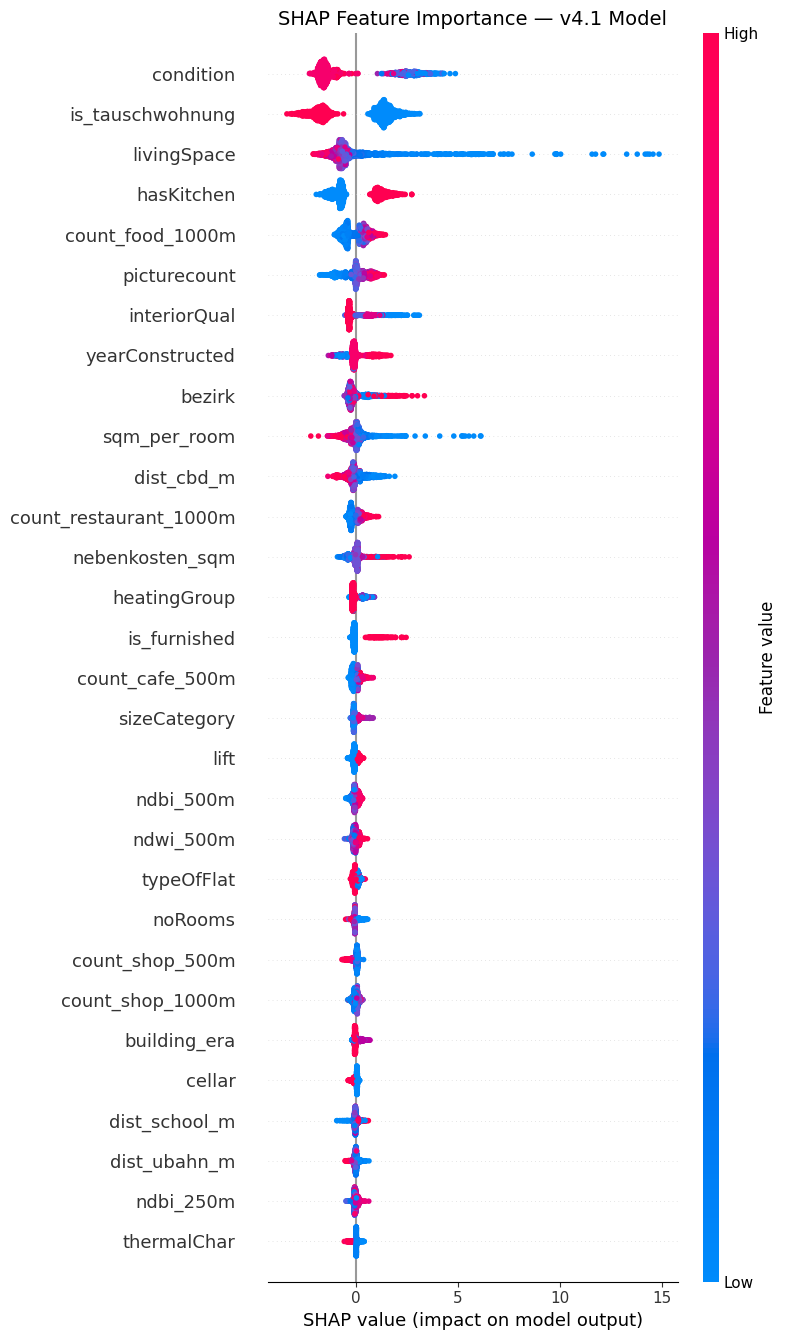

=== Top 25 Features by Mean |SHAP| ===
   1. condition                    1.799  [STRUCT]
   2. is_tauschwohnung             1.626  [NLP]
   3. livingSpace                  1.174  [STRUCT]
   4. hasKitchen                   1.075  [STRUCT]
   5. count_food_1000m             0.492  [SPATIAL]
   6. picturecount                 0.465  [NEW]
   7. interiorQual                 0.440  [STRUCT]
   8. yearConstructed              0.356  [STRUCT]
   9. bezirk                       0.351  [STRUCT]
  10. sqm_per_room                 0.338  [STRUCT]
  11. dist_cbd_m                   0.332  [SPATIAL]
  12. count_restaurant_1000m       0.227  [SPATIAL]
  13. nebenkosten_sqm              0.212  [NEW]
  14. heatingGroup                 0.192  [NEW]
  15. is_furnished                 0.173  [NLP]
  16. count_cafe_500m              0.142  [SPATIAL]
  17. sizeCategory                 0.115  [NEW]
  18. lift                         0.110  [STRUCT]
  19. ndbi_500m                    0.108  [SPATIAL]
  20.

In [10]:
# SHAP for v4.1
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

fig, ax = plt.subplots(figsize=(10, 14))
shap.summary_plot(shap_values, X_test, feature_names=ALL_FEATURES, show=False, max_display=30)
plt.title('SHAP Feature Importance — v4.1 Model', fontsize=14)
plt.tight_layout()
plt.show()

# Top features
mean_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({'feature': ALL_FEATURES, 'mean_abs_shap': mean_shap}).sort_values('mean_abs_shap', ascending=False)

print('=== Top 25 Features by Mean |SHAP| ===')
for i, (_, row) in enumerate(shap_df.head(25).iterrows()):
    if row['feature'] in SPATIAL_FEATURES:
        tag = 'SPATIAL'
    elif row['feature'] in BINARY_FEATURES and row['feature'].startswith('is_'):
        tag = 'NLP'
    elif row['feature'] in ['picturecount', 'nebenkosten_sqm', 'sizeCategory', 'heatingGroup']:
        tag = 'NEW'
    else:
        tag = 'STRUCT'
    print(f'  {i+1:>2}. {row["feature"]:<28} {row["mean_abs_shap"]:.3f}  [{tag}]')

# Count new features in top 20
new_in_top20 = sum(1 for _, r in shap_df.head(20).iterrows() 
                   if r['feature'] not in ['livingSpace','noRooms','yearConstructed','floor','numberOfFloors',
                                            'thermalChar','sqm_per_room','balcony','hasKitchen','lift',
                                            'cellar','garden','newlyConst','condition','interiorQual',
                                            'typeOfFlat','heatingType','building_era','bezirk'] + SPATIAL_FEATURES[:9])
print(f'\nNew features in top 20: {new_in_top20}')

## Step 9: Save v4.1 Artifacts

In [11]:
# Save v4.1 artifacts (only if improvement over v4.0)
if r2 > 0.7083:
    joblib.dump(final_model, MODEL_DIR / 'xgboost_rent_v4.joblib')
    joblib.dump(explainer, MODEL_DIR / 'shap_explainer_v4.joblib')
    joblib.dump(encoder, MODEL_DIR / 'feature_encoder_v4.joblib')
    
    data_hash = hashlib.sha256(open(PROC_DIR / 'units.parquet', 'rb').read()).hexdigest()
    
    config = {
        'model_version': 'v4.1.0',
        'trained_at': datetime.now().isoformat(),
        'data_source': 'apify_immoscout24_berlin_2026_03',
        'data_files': {
            'units': 'data/processed/units.parquet',
            'listings': 'data/processed/listings.parquet',
            'spatial_unit': 'data/processed/spatial_unit.parquet',
        },
        'data_file_sha256': data_hash,
        'inflation_factor': 1.0,
        'inflation_factor_active': False,
        'features': ALL_FEATURES,
        'numeric_features': NUMERIC_FEATURES,
        'binary_features': BINARY_FEATURES,
        'categorical_features': CATEGORICAL_FEATURES,
        'spatial_features': SPATIAL_FEATURES,
        'spatial_level': 'unit',
        'best_params': {**best_params, 'n_estimators': final_model.best_iteration},
        'train_size': len(X_train),
        'test_size': len(X_test),
        'metrics': {'r2': round(r2, 4), 'rmse': round(rmse, 4), 'mae': round(mae, 4)},
        'improvements_over_v4': {
            'better_missing_data': 'yearConstructed from titles, thermalChar by heatingType, floor from typeOfFlat',
            'new_features': 'heatingGroup, sizeCategory, NLP title features, picturecount, nebenkosten_sqm',
            'hyperparameter_tuning': 'RandomizedSearchCV 30 iterations, 3-fold CV',
        },
        'artifacts': {
            'model': 'models/xgboost_rent_v4.joblib',
            'shap_explainer': 'models/shap_explainer_v4.joblib',
            'feature_encoder': 'models/feature_encoder_v4.joblib',
        },
    }
    
    with open(MODEL_DIR / 'model_config.json', 'w') as f:
        json.dump(config, f, indent=2)
    
    print(f'=== v4.1 Saved ===')
    print(f'  R² improved: 0.7083 → {r2:.4f} ({r2 - 0.7083:+.4f})')
    print(f'  RMSE improved: 4.21 → {rmse:.2f} ({rmse - 4.21:+.2f})')
    print(f'  Features: {len(ALL_FEATURES)}')
    print(f'  Best params: {best_params}')
else:
    print(f'  v4.1 R² ({r2:.4f}) did not improve over v4.0 (0.7083) — NOT saving.')
    print(f'  Consider: more data, different features, or model architecture changes.')

=== v4.1 Saved ===
  R² improved: 0.7083 → 0.7361 (+0.0278)
  RMSE improved: 4.21 → 4.00 (-0.21)
  Features: 55
  Best params: {'subsample': 0.9, 'reg_lambda': 1.0, 'reg_alpha': 0, 'min_child_weight': 10, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 0.6}


## Step 10: Tauschwohnung Analysis + Log-Transform

41% of listings are apartment swaps (Tauschwohnungen). Let's check if they have different rent distributions and whether filtering them improves the model for actual market rent prediction.

=== Tauschwohnung vs Regular ===
  Tauschwohnung: 3,428 (41.5%)
  Regular:       4,828 (58.5%)

  rent_sqm:
    Tausch median:  10.37 €/m²
    Regular median: 19.00 €/m²
    Difference:     +8.62 €/m²


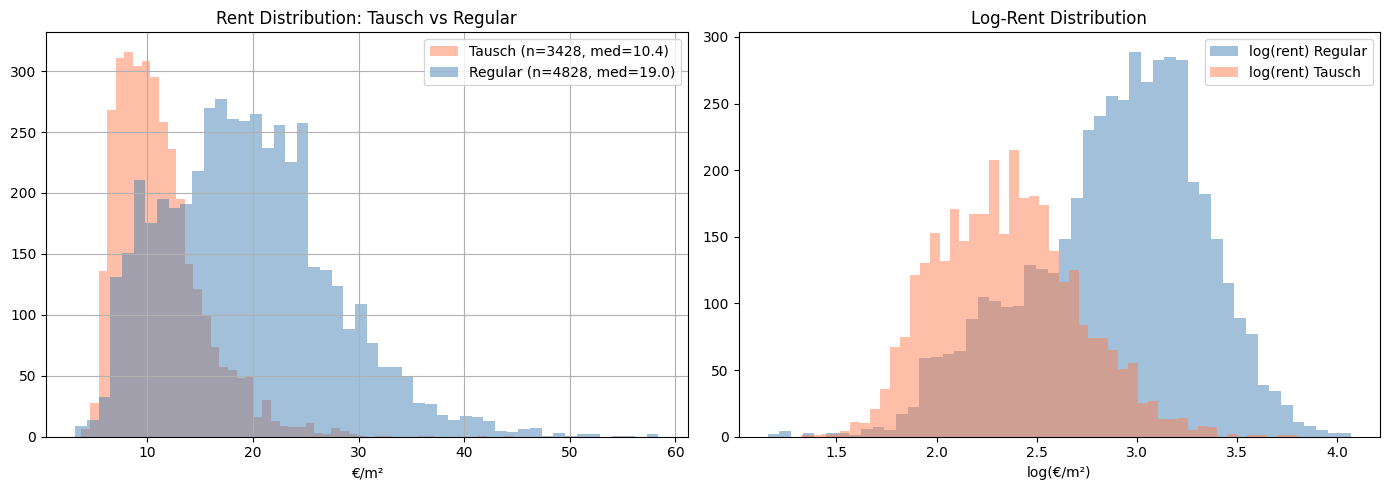

In [12]:
# Analyze Tauschwohnung vs regular listings
tausch = df[df['is_tauschwohnung'] == 1]
regular = df[df['is_tauschwohnung'] == 0]

print(f'=== Tauschwohnung vs Regular ===')
print(f'  Tauschwohnung: {len(tausch):,} ({100*len(tausch)/len(df):.1f}%)')
print(f'  Regular:       {len(regular):,} ({100*len(regular)/len(df):.1f}%)')
print(f'\n  rent_sqm:')
print(f'    Tausch median:  {tausch["rent_sqm"].median():.2f} €/m²')
print(f'    Regular median: {regular["rent_sqm"].median():.2f} €/m²')
print(f'    Difference:     {regular["rent_sqm"].median() - tausch["rent_sqm"].median():+.2f} €/m²')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
tausch['rent_sqm'].hist(bins=50, alpha=0.5, label=f'Tausch (n={len(tausch)}, med={tausch["rent_sqm"].median():.1f})', color='coral', ax=ax)
regular['rent_sqm'].hist(bins=50, alpha=0.5, label=f'Regular (n={len(regular)}, med={regular["rent_sqm"].median():.1f})', color='steelblue', ax=ax)
ax.set_title('Rent Distribution: Tausch vs Regular')
ax.set_xlabel('€/m²')
ax.legend()

ax = axes[1]
ax.hist(np.log(regular['rent_sqm']), bins=50, alpha=0.5, label='log(rent) Regular', color='steelblue')
ax.hist(np.log(tausch['rent_sqm']), bins=50, alpha=0.5, label='log(rent) Tausch', color='coral')
ax.set_title('Log-Rent Distribution')
ax.set_xlabel('log(€/m²)')
ax.legend()

plt.tight_layout()
plt.show()

In [13]:
# Train 3 variants and compare:
# A) v4.1 as-is (baseline for this comparison)
# B) Regular listings only (remove Tauschwohnungen)
# C) Log-transform target (all data)
# D) Regular + log-transform (combined)

results = {}

for variant_name, use_log, filter_tausch in [
    ('v4.1 (all data)',           False, False),
    ('Regular only',              False, True),
    ('All + log(rent)',           True,  False),
    ('Regular + log(rent)',       True,  True),
]:
    df_v = df.copy()
    if filter_tausch:
        df_v = df_v[df_v['is_tauschwohnung'] == 0]
    
    X_v = df_v[ALL_FEATURES].copy()
    y_v = np.log(df_v[TARGET]) if use_log else df_v[TARGET].copy()
    
    X_tr_v, X_te_v, y_tr_v, y_te_v = train_test_split(X_v, y_v, test_size=0.2, random_state=42)
    X_trn, X_vld, y_trn, y_vld = train_test_split(X_tr_v, y_tr_v, test_size=0.15, random_state=42)
    
    m = xgb.XGBRegressor(
        **best_params,
        n_estimators=2000,
        random_state=42,
        n_jobs=-1,
        early_stopping_rounds=50,
        eval_metric='rmse',
    )
    m.fit(X_trn, y_trn, eval_set=[(X_vld, y_vld)], verbose=0)
    
    y_pred_v = m.predict(X_te_v)
    
    # Convert back from log if needed for fair comparison
    if use_log:
        y_actual = np.exp(y_te_v)
        y_predicted = np.exp(y_pred_v)
    else:
        y_actual = y_te_v
        y_predicted = y_pred_v
    
    r2_v = r2_score(y_actual, y_predicted)
    rmse_v = np.sqrt(mean_squared_error(y_actual, y_predicted))
    mae_v = mean_absolute_error(y_actual, y_predicted)
    
    results[variant_name] = {
        'r2': r2_v, 'rmse': rmse_v, 'mae': mae_v,
        'n_train': len(X_tr_v), 'n_test': len(X_te_v),
        'iters': m.best_iteration,
    }

print('=' * 75)
print('  VARIANT COMPARISON')
print('=' * 75)
print(f'  {"Variant":<25} {"N_train":>8} {"N_test":>7} {"R²":>8} {"RMSE":>8} {"MAE":>8} {"Iters":>6}')
print(f'  {"-"*72}')
for name, res in results.items():
    print(f'  {name:<25} {res["n_train"]:>8,} {res["n_test"]:>7,} {res["r2"]:>8.4f} {res["rmse"]:>8.2f} {res["mae"]:>8.2f} {res["iters"]:>6}')

best_variant = max(results.items(), key=lambda x: x[1]['r2'])
print(f'\n  Best: {best_variant[0]} (R²={best_variant[1]["r2"]:.4f})')

  VARIANT COMPARISON
  Variant                    N_train  N_test       R²     RMSE      MAE  Iters
  ------------------------------------------------------------------------
  v4.1 (all data)              6,604   1,652   0.7361     4.00     2.92    293
  Regular only                 3,862     966   0.6797     4.48     3.19    403
  All + log(rent)              6,604   1,652   0.7166     4.15     2.95    302
  Regular + log(rent)          3,862     966   0.6743     4.52     3.17    464

  Best: v4.1 (all data) (R²=0.7361)
